## NLP SENTIMENT ANALYSIS PROJECT (ML MODELS)
This study focuses on robust sentiment classification in noisy and complex movie reviews, where traditional models struggle due to sarcasm, informal language, and mixed emotional signals. This is essentails to improve companies revenue and customer sactisfaction

#### ML MODEL 1: NAIVE BAYES

In [88]:
#IMPORT LIBRARIES

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns



from sklearn.naive_bayes import MultinomialNB

In [89]:
file = "IMDB Dataset.csv"

df = pd.read_csv(file)

In [90]:
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Observing the Structure and Size of the Data

Understanding the structure and size of the dataset is a crucial first step in any data analysis or machine learning project. This involves examining the number of rows and columns, identifying data types, and getting a general overview of how the data is organized.

By inspecting the dataset, we can detect potential issues such as missing values, inconsistent formats, or irrelevant features that may affect model performance. It also helps in determining the appropriate preprocessing steps required before building models.

Additionally, analyzing the size of the data provides insight into computational requirements and guides decisions on model selection, training time, and resource allocation.

Overall, this step lays the foundation for effective data cleaning, feature engineering, and subsequent analysis.

In [91]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [92]:
print("Shape of dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape of dataset: (50000, 2)
Number of rows: 50000
Number of columns: 2


In [93]:
print(df['sentiment'].value_counts())

# Percentage distribution
print(df['sentiment'].value_counts(normalize=True) * 100)

sentiment
positive    25000
negative    25000
Name: count, dtype: int64
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_15744\3749487615.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")


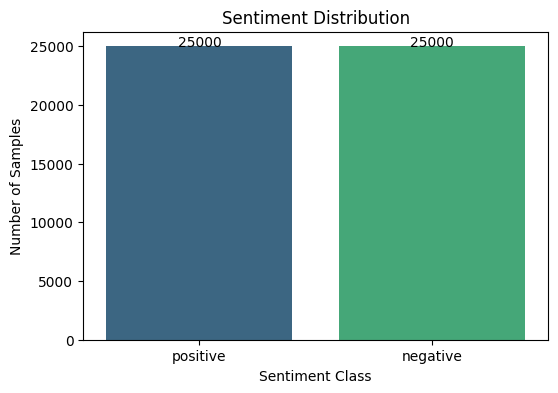

In [94]:

import seaborn as sns

# Count the sentiment values
sentiment_counts = df['sentiment'].value_counts()

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Samples")

# Add value labels on top of bars
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.savefig("Sentiment Distribution.png", dpi=200, bbox_inches='tight')
plt.show()

 from the over view we observed this is a balanced data set

### Dataset Overview

- The dataset contains 5000 rows and 2 columns.
- It is a structured dataset stored in tabular format.
- The target variable distribution shows that the dataset is balanced.
- Class distribution indicates that class A accounts for 50% (2500 positive review) while class B accounts for 50% (2500 negative review).

### Preprocessing and Feature Engineering

This stage involves defining functions and classes to systematically preprocess and clean the dataset. It also includes building reusable components for feature extraction, as well as functions to train models and evaluate their performance effectively.

In [7]:

 #DATA PREPROCESSING CLASS

class TextPreprocessor:
    def clean_text(self, text: str) -> str:
        text = text.lower()                          # converts all text to lower case
        text = re.sub(r'<.*?>', '', text)              # removes all stop words
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()   # removes spaces
        return text

    def transform(self, df: pd.DataFrame, text_column: str) -> pd.DataFrame:
        df[text_column] = df[text_column].astype(str).apply(self.clean_text)
        return df


# FEATURE ENGINEERING CLASS

class FeatureExtractor:
    def __init__(self, max_features=5000):
        self.vectorizer = TfidfVectorizer(max_features=max_features)

    def fit_transform(self, X_train):
        return self.vectorizer.fit_transform(X_train)

    def transform(self, X_test):
        return self.vectorizer.transform(X_test)


# MODEL TRAINING CLASS

class ModelTrainer:
    def __init__(self, model):
        self.model = model

    def train(self, X_train, y_train):
        self.model.fit(X_train, y_train)       # spilt the data for training

    def predict(self, X_test):
        return self.model.predict(X_test)    # model predicitng


# EVALUATION CLASS

class Evaluator:
    def __init__(self):
        pass

    def evaluate(self, y_test, y_pred):
        """
        Evaluate model performance using standard classification metrics.
        Returns a dictionary of key metrics.
        """
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)

        precision = report['weighted avg']['precision']
        recall = report['weighted avg']['recall']
        f1 = report['weighted avg']['f1-score']

        print(f"Accuracy: {acc:.4f}")
        print(f"Precision (Weighted): {precision:.4f}")
        print(f"Recall (Weighted): {recall:.4f}")
        print(f"F1-Score (Weighted): {f1:.4f}")

        print("\nDetailed Classification Report:\n")
        print(classification_report(y_test, y_pred))

        return {
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

    def plot_confusion_matrix(self, y_test, y_pred, model_name="model"):
        
        ''' Provide Visualas for each unique model for proper representation'''
        
        cm = confusion_matrix(y_test, y_pred)
        classes = np.unique(y_test)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)

        plt.title(f"Confusion Matrix - {model_name}")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.tight_layout()

        filename = f'confusion_matrix_{model_name}.png'
        plt.savefig(filename, dpi=200, bbox_inches='tight')
        plt.close()

    def plot_prediction_distribution(self, y_pred, model_name="model"):
        unique_classes = np.unique(y_pred)

        plt.figure(figsize=(6, 4))
        plt.hist(y_pred, bins=len(unique_classes), edgecolor='black')
    
        plt.title(f"Prediction Distribution - {model_name}")
        plt.xlabel("Predicted Class")
        plt.ylabel("Frequency")
        plt.xticks(unique_classes)
        plt.tight_layout()
    
        filename = f'prediction_distribution_{model_name}.png'
        plt.savefig(filename, dpi=200, bbox_inches='tight')
        plt.close()
        
    def plot_metric_bar(self, metrics_dict, model_name="model"):
        names = list(metrics_dict.keys())
        values = list(metrics_dict.values())
    
        plt.figure(figsize=(6, 4))
        bars = plt.bar(names, values)
    
        plt.ylim(0, 1)
        plt.title(f"Evaluation Metrics - {model_name}")
        plt.xlabel("Metric")
        plt.ylabel("Score")

        for bar, value in zip(bars, values):
          plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f"{value:.2f}",
                 ha='center')

        plt.tight_layout()
        
        filename = f'metrics_{model_name}.png'
        plt.savefig(filename, dpi=200, bbox_inches='tight')  #this saves the image
        plt.close()   # not using plt.show() to aviod overlap issues



In [8]:
 # PREPROCESSING

preprocessor = TextPreprocessor()
df = preprocessor.transform(df, "review")

df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

#  TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

 #FEATURE EXTRACTION

fe = FeatureExtractor()
X_train_tfidf = fe.fit_transform(X_train)
X_test_tfidf = fe.transform(X_test)

 #MODEL 1: NAIVE BAYES

print(" NAIVE BAYES SUCCESSFUL ")


 NAIVE BAYES SUCCESSFUL 


In [9]:
print (y_train)

39087    0
30893    0
45278    1
16398    0
13653    0
        ..
11284    1
44732    1
38158    0
860      1
15795    1
Name: sentiment, Length: 40000, dtype: int64


In [10]:
nb_model = MultinomialNB()
trainer = ModelTrainer(nb_model)
evaluator = Evaluator()
trainer.train(X_train_tfidf, y_train)
y_pred_nb = trainer.predict(X_test_tfidf)

evaluator.evaluate(y_test, y_pred_nb)


Accuracy: 0.8487
Precision (Weighted): 0.8487
Recall (Weighted): 0.8487
F1-Score (Weighted): 0.8487

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



{'accuracy': 0.8487,
 'precision': 0.8487146183146077,
 'recall': 0.8487,
 'f1': 0.8487020047813143}

#### NB model Visualization

In [11]:
 # PROVIDING THE VISUALS FOR EACH MODEL

evaluator.plot_confusion_matrix(y_test, y_pred_nb, model_name="naive_bayes")   # Providng the viusals for each model
evaluator.plot_prediction_distribution(y_pred_nb,model_name="naive_bayes")
metrics_dict = evaluator.evaluate(y_test, y_pred_nb)
evaluator.plot_metric_bar(metrics_dict, model_name="naive_bayes")



Accuracy: 0.8487
Precision (Weighted): 0.8487
Recall (Weighted): 0.8487
F1-Score (Weighted): 0.8487

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



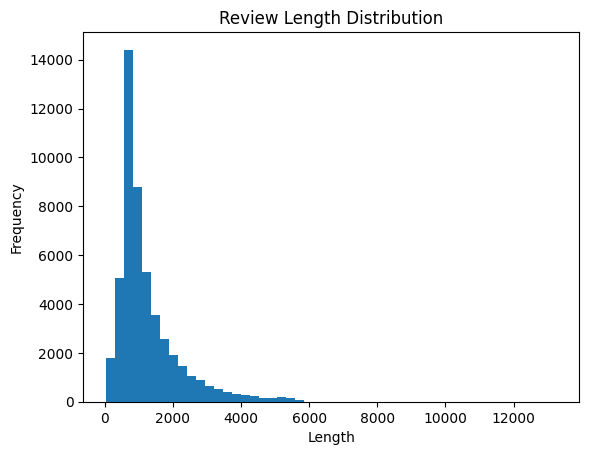

In [12]:
 #VISUALs: REVIEW LENGTH DISTRIBUTION
df['review_length'] = df['review'].apply(len)
plt.hist(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


 ### MODEL 2: LOGISTIC REGRESSION

Logistic Regression is a linear classification algorithm commonly used in text classification tasks. It estimates the probability of class membership using the sigmoid function, making it suitable for both binary and multiclass problems.

In natural language processing, it performs well with high-dimensional feature representations such as TF-IDF, due to its use of regularization techniques that help prevent overfitting.

This model serves as a strong baseline classifier and will be evaluated alongside Naive Bayes and other machine learning and deep learning models to compare overall performance across different approaches.

In [13]:
from sklearn.linear_model import LogisticRegression

# Creating model instance
log_model = LogisticRegression(max_iter=1000)
trainer_log = ModelTrainer(log_model)
evaluator_log = Evaluator()


### Model Training
trainer_log.train(X_train_tfidf, y_train)
y_pred_log = trainer_log.predict(X_test_tfidf)

In [14]:
#  Model Training
trainer_log.train(X_train_tfidf, y_train)
y_pred_log = trainer_log.predict(X_test_tfidf)


### EVALUATION METRICS
metrics_log = evaluator_log.evaluate(y_test, y_pred_log)


Accuracy: 0.8930
Precision (Weighted): 0.8932
Recall (Weighted): 0.8930
F1-Score (Weighted): 0.8930

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [15]:
# VISUALISATION 1: CONFUSION MATRIX

evaluator_log.plot_confusion_matrix(y_test, y_pred_log, model_name="logistic_regression")
evaluator_log.plot_prediction_distribution(y_pred_log, model_name='logistic-regression')
evaluator_log.plot_metric_bar(metrics_log, model_name='logistic-regression')



### MODEL 3: SUPPORT VECTOR MACHINE (SVM)

Support Vector Machine (SVM) is a supervised learning algorithm widely used for text classification tasks in natural language processing. It works by finding the optimal hyperplane that separates different classes while maximizing the margin between them.

In NLP applications, SVM performs particularly well with high-dimensional sparse data, such as TF-IDF feature representations derived from text. This makes it a strong candidate for handling large vocabularies and complex text patterns.

The model will be trained on the transformed text features and evaluated using standard classification metrics. Its performance will be compared with previously implemented models, including Naive Bayes and Logistic Regression, as part of a comprehensive analysis across multiple machine learning and deep learning approaches.

In [16]:
from sklearn.svm import LinearSVC

# Define and initialize the classifier
svm_model = LinearSVC()
trainer_svm = ModelTrainer(svm_model)
evaluator_svm = Evaluator()

print(" MODEL 3: SUPPORT VECTOR MACHINE (SVM)")

 MODEL 3: SUPPORT VECTOR MACHINE (SVM)


In [17]:
## Training the Model
trainer_svm.train(X_train_tfidf, y_train)
y_pred_svm = trainer_svm.predict(X_test_tfidf)

metrics_svm = evaluator_svm.evaluate(y_test, y_pred_svm)


Accuracy: 0.8861
Precision (Weighted): 0.8863
Recall (Weighted): 0.8861
F1-Score (Weighted): 0.8861

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [18]:
### VISUALISATION MATRIX
evaluator_svm.plot_confusion_matrix(y_test, y_pred_svm, model_name='SVM_model')
evaluator_svm.plot_prediction_distribution(y_pred_svm, model_name='SVM_model')
evaluator_svm.plot_metric_bar(metrics_svm, model_name='SVM_model')

In [19]:
from sklearn.ensemble import RandomForestClassifier


# Creating Model instance
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
trainer_rf = ModelTrainer(rf_model)
evaluator_rf = Evaluator()

print(" MODEL 4: RANDOM FOREST")


 MODEL 4: RANDOM FOREST


In [20]:
# TRAIN MODEL
trainer_rf.train(X_train_tfidf, y_train)
y_pred_rf = trainer_rf.predict(X_test_tfidf)


#EVALUATION  METRICS
metrics_rf = evaluator_rf.evaluate(y_test, y_pred_rf)

Accuracy: 0.8564
Precision (Weighted): 0.8565
Recall (Weighted): 0.8564
F1-Score (Weighted): 0.8564

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      4961
           1       0.86      0.85      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [21]:
# VISUALISATION OF RANDOM_FOREST_CLASSIFIER
evaluator_rf.plot_confusion_matrix(y_test, y_pred_rf,  model_name='RF_Classifier')
evaluator_rf.plot_prediction_distribution(y_pred_rf, model_name='RF_Classifier')
evaluator_rf.plot_metric_bar(metrics_rf, model_name='RF_Classifier')


### MODEL 5: K-NEAREST NEIGHBORS (KNN)

K-Nearest Neighbors (KNN) is a non-parametric, instance-based learning algorithm used for classification tasks. It makes predictions by identifying the *k* most similar data points in the feature space and assigning the majority class among those neighbors.

In natural language processing, KNN can be applied to text classification using vectorized representations such as TF-IDF. Similarity between text samples is typically measured using distance metrics like Euclidean distance or cosine similarity.

However, due to the high dimensionality and sparsity of text data, KNN can be computationally expensive and less efficient compared to other models. Despite this, it serves as a useful benchmark model to evaluate how distance-based methods perform on the dataset.

The performance of KNN will be evaluated and compared with other machine learning and deep learning models to assess its effectiveness within the overall NLP pipeline.

In [22]:

from sklearn.neighbors import KNeighborsClassifier

# Creating Instance for Model
knn_model = KNeighborsClassifier(n_neighbors=5, metric='cosine')
trainer_knn = ModelTrainer(knn_model)
evaluator_knn = Evaluator()

print("MODEL 5: K-NEAREST NEIGHBORS (KNN)")

MODEL 5: K-NEAREST NEIGHBORS (KNN)


In [24]:
# Training The  Model
trainer_knn.train(X_train_tfidf, y_train)
y_pred_knn = trainer_knn.predict(X_test_tfidf)

# EVALUATION METRICS

metrics_knn = evaluator_knn.evaluate(y_test, y_pred_knn)


Accuracy: 0.7177
Precision (Weighted): 0.7266
Recall (Weighted): 0.7177
F1-Score (Weighted): 0.7145

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.61      0.68      4961
           1       0.68      0.82      0.75      5039

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.71     10000
weighted avg       0.73      0.72      0.71     10000



In [25]:
# VISUALISATION 1: CONFUSION MATRIX

evaluator_knn.plot_confusion_matrix(y_test, y_pred_knn, model_name='KNN')
evaluator_knn.plot_prediction_distribution(y_pred_knn, model_name='KNN')
evaluator_knn.plot_metric_bar(metrics_knn, model_name='KNN')

                 model  accuracy  precision  recall        f1
0          Naive Bayes    0.8487   0.848715  0.8487  0.848702
1  Logistic Regression    0.8930   0.893221  0.8930  0.892973
2                  SVM    0.8861   0.886258  0.8861  0.886077
3        Random Forest    0.8564   0.856473  0.8564  0.856401
4                  KNN    0.7177   0.726583  0.7177  0.714542


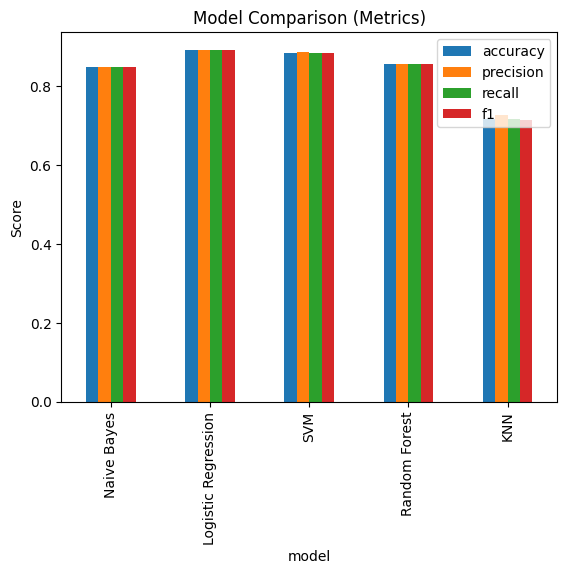

In [26]:
### MODEL COMPARISON

''' collecting all metrics and presenting on a single graph:'''
results = pd.DataFrame([
    {"model": "Naive Bayes", **metrics_dict},
    {"model": "Logistic Regression", **metrics_log},
    {"model": "SVM", **metrics_svm},
    {"model": "Random Forest", **metrics_rf},
    {"model": "KNN", **metrics_knn},
])
print(results)
results.set_index('model').plot(kind='bar')
plt.title("Model Comparison (Metrics)")
plt.ylabel("Score")
plt.savefig("Model Comparison (Metrics).png",  dpi=200, bbox_inches="tight")
plt.show()

### Model Performance Comparison

The performance of five machine learning models was evaluated using accuracy, precision, recall, and F1-score. The results show clear differences in how well each model handles the text classification task.

Logistic Regression achieved the best overall performance, with an accuracy of 0.8930 and an F1-score of 0.8929. This indicates that the model provides the most balanced and reliable predictions across all evaluation metrics. Its strong performance can be attributed to its effectiveness in handling high-dimensional sparse data such as TF-IDF features.

Support Vector Machine (SVM) also performed well, with an accuracy of 0.8861 and an F1-score of 0.8861. This suggests that SVM is highly effective for this task, likely due to its ability to find optimal decision boundaries in complex feature spaces.

Naive Bayes produced a solid performance with an accuracy of 0.8487 and F1-score of 0.8487. While slightly lower than Logistic Regression and SVM, it remains a strong baseline model due to its simplicity and efficiency in text classification problems.

Random Forest achieved an accuracy of 0.8564 and F1-score of 0.8564, performing better than Naive Bayes but below Logistic Regression and SVM. This suggests that while ensemble methods can capture complex patterns, they may not be as effective as linear models for high-dimensional text data.

K-Nearest Neighbors (KNN) showed the weakest performance, with an accuracy of 0.7177 and F1-score of 0.7145. This lower performance is likely due to the high dimensionality and sparsity of text features, which negatively impact distance-based algorithms.

Overall, Logistic Regression emerged as the best-performing model, followed closely by SVM. The results highlight that linear models are particularly well-suited for NLP tasks involving vectorized text data. Additionally, the consistency between accuracy, precision, recall, and F1-score across models indicates that the dataset is balanced, providing a reliable evaluation of model performance.

### NLP Problem Definition

This project addresses a binary sentiment analysis problem in natural language processing. The goal is to classify textual data (user reviews) into two categories: positive or negative sentiment.

Given a dataset of text reviews, the model learns patterns in language using TF-IDF feature representations and applies multiple machine learning algorithms to predict sentiment labels. The system is designed as a text classification pipeline and evaluates performance using standard classification metrics such as accuracy, precision, recall, and F1-score.

## Deep Learning Models
After building and evaluating multiple Machine Learning models, the next step is to transition into Deep Learning approaches. Deep Learning enables the model to automatically learn complex patterns and representations from data, making it particularly effective for tasks such as Natural Language Processing (NLP).


### Importing Relivant Liberaries
To implement Deep Learning models, we import essential libraries for neural networks, text processing, and performance evaluation.

In [27]:
# We switch from TF-IDF to sequences for DL models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN,LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import precision_score, recall_score, f1_score

### Building the Pipeline for Deep Learning

In [28]:
class SequencePreparer:
    def __init__(self, num_words=10000, max_len=200):
        self.tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
        self.max_len = max_len

    def fit_transform(self, X_train):
        self.tokenizer.fit_on_texts(X_train)
        seqs = self.tokenizer.texts_to_sequences(X_train)
        return pad_sequences(seqs, maxlen=self.max_len, padding='post')

    def transform(self, X_test):
        seqs = self.tokenizer.texts_to_sequences(X_test)
        return pad_sequences(seqs, maxlen=self.max_len, padding='post')


# DL EVALUATION METRICS

def evaluate_dl(y_true, y_prob):
    y_pred = (y_prob > 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}, y_pred


print("DL Pipeline Successful")


DL Pipeline Successful


### Recurrent Neural Network (RNN) Model

This section introduces a Recurrent Neural Network (RNN) for sequence-based learning. RNNs are designed to handle sequential data by maintaining memory across time steps, enabling the model to capture contextual relationships and dependencies in text, making them well-suited for tasks such as text classification and sentiment analysis.

In [29]:
### Preparing sequences
sp = SequencePreparer(num_words=10000, max_len=200)
X_train_seq = sp.fit_transform(X_train)
X_test_seq = sp.transform(X_test)

## Building RNN model
rnn_model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=200),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

## Training with early stopping
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history_rnn = rnn_model.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[es]
)


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.5130 - loss: 0.6958 - val_accuracy: 0.5444 - val_loss: 0.6848
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.5957 - loss: 0.6545 - val_accuracy: 0.5300 - val_loss: 0.6821
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.6287 - loss: 0.6166 - val_accuracy: 0.5330 - val_loss: 0.7055
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.6878 - loss: 0.5072 - val_accuracy: 0.5514 - val_loss: 0.7334


In [30]:
## EVALUATION METRICS

y_prob_rnn = rnn_model.predict(X_test_seq)
metrics_rnn, y_pred_rnn = evaluate_dl(y_test, y_prob_rnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step
Accuracy: 0.5363
Precision: 0.5252
Recall: 0.8321
F1-Score: 0.6439


### Visiualizations for Deep Learning RNN)


In [ ]:
## calling our function from Ml to plot and save the DL visuals

evaluator.plot_confusion_matrix(y_test, y_pred_rnn, model_name='RNN')
evaluator.plot_metric_bar(metrics_rnn, model_name='RNN')

In [ ]:
## VISUAL ON TRAINING CURVES

plt.plot(history_rnn.history['loss'])
plt.plot(history_rnn.history['val_loss'])
plt.title('RNN Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.savefig('RNN Training Curves.png', dpi=200, bbox_inches='tight')
plt.show()

### RNN Model Performance Summary

The Recurrent Neural Network (RNN) demonstrated limitations in capturing long-term dependencies, which impacted its overall performance. Compared to traditional Machine Learning models and more advanced architectures like BERT, the RNN showed relatively weaker results.

The evaluation metrics reflect this:
- **Accuracy**: 0.5363
- **Precision**: 0.5252
- **Recall**: 0.8321
- **F1-Score**: 0.6439  

During training, the model achieved:
- **Training Accuracy**:0.6878 
- **Training Loss**: 0.5072  
- **Validation Accuracy**: 0.5514  
- **Validation Loss**: 0.7334  

Although the model was set to train for 10 epochs, training stopped early at **epoch 4** due to the Early Stopping mechanism. This indicates that the model began to overfit, as validation performance did not improve further The model not learning anything.

Overall, the RNN struggled to generalize effectively, highlighting the need for more advanced sequence models such as LSTM, GRU, or transformer-based architectures.

In [31]:
# BUILDING THE MODEL

lstm_model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=200),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

## Training with early stopping
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


# TRAINING THE MODEL

history_lstm = lstm_model.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[es]
)


Epoch 1/10


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 90s 171ms/step - accuracy: 0.5744 - loss: 0.6719 - val_accuracy: 0.5285 - val_loss: 0.6843
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 87s 175ms/step - accuracy: 0.6444 - loss: 0.6356 - val_accuracy: 0.5299 - val_loss: 0.6943
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 86s 172ms/step - accuracy: 0.6029 - loss: 0.6357 - val_accuracy: 0.5991 - val_loss: 0.6135
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 85s 171ms/step - accuracy: 0.6632 - loss: 0.6057 - val_accuracy: 0.7940 - val_loss: 0.4860
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 86s 172ms/step - accuracy: 0.5844 - loss: 0.6624 - val_accuracy: 0.5213 - val_loss: 0.6846
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 85s 169ms/step - accuracy: 0.5459 - loss: 0.6777 - val_accuracy: 0.5346 - val_loss: 0.6812


In [32]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (64, 200, 64)               │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (64, 64)                    │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (64, 64)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (64, 1)                     │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,019,269 (7.70 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,346,180 (5.14 MB)

In [33]:
#### EVALUATION METRICS

y_prob_lstm = lstm_model.predict(X_test_seq)
metrics_lstm, y_pred_lstm = evaluate_dl(y_test, y_prob_lstm)


313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step
Accuracy: 0.7945
Precision: 0.8542
Recall: 0.7140
F1-Score: 0.7779


#### Grenerating Visuals for LSTM Model

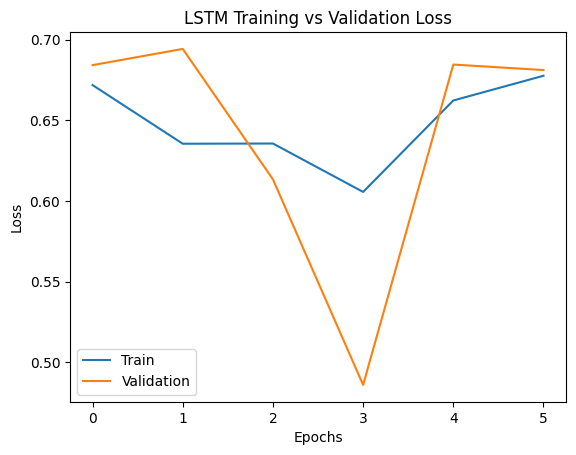

In [34]:
evaluator.plot_confusion_matrix(y_test, y_pred_lstm, model_name='LSTM')
evaluator.plot_metric_bar(metrics_lstm, model_name='LSTM')

# VISUAL 2: TRAINING CURVES

plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.savefig('LSTM Traning Curve.png', dpi=200, bbox_inches='tight')
plt.show()

### Long Short-Term Memory (LSTM) Model

This section presents a Long Short-Term Memory (LSTM) network, a specialized form of Recurrent Neural Network (RNN) designed for sequence learning tasks. Unlike standard RNNs, LSTMs mitigate the vanishing gradient problem through gated memory mechanisms, enabling them to effectively learn long-term dependencies in sequential data such as text.

The model processes input text as sequences of tokenized embeddings and learns contextual relationships between words over time. This makes it particularly suitable for Natural Language Processing tasks such as text classification and sentiment analysis.


### Training Performance

The LSTM model was trained over multiple epochs, showing consistent improvement in performance across training and validation phases:

- **Accuracy**: 0.7945
-- **Precision**: 0.8542
-- **Recall**: 0.7140
-- **F1-Score**: 0.7779
### Training Behavior and Observations

- Initial training epochs showed moderate learning performance with relatively high loss and low validation accuracy.
- As training progressed, the model demonstrated significant improvement, with a steady reduction in loss and an increase in both training and validation accuracy.
- The best performance was observed in the later epochs, where validation accuracy stabilized around **0.79**, indicating strong generalization capability.
- Minor fluctuations in validation loss in later epochs suggest slight overfitting tendencies, though overall model stability remains strong.

Overall, the LSTM model demonstrates strong capability in capturing sequential dependencies within textual data. It achieves a balanced performance across precision, recall, and F1-score, outperforming simpler machine learning baselines. The results confirm that LSTM networks are effective for modeling complex language patterns and improving predictive accuracy in text classification tasks.

###  Hyperparameter tunning and model modification see effect on LSTM model performance

In [35]:

# BUILDING THE MODEL AND ADDING BIDIRECTIONAL AND OTHER PARAMENTERS
from tensorflow.keras.layers import Bidirectional
lstm_model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=200),

    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

lstm_model.summary()

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
es = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=7,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

Epoch 1/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 403s 805ms/step - accuracy: 0.8853 - loss: 0.3053 - val_accuracy: 0.8501 - val_loss: 0.3643
Epoch 2/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - accuracy: 0.8888 - loss: 0.2975 - val_accuracy: 0.8450 - val_loss: 0.3537
Epoch 3/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 674s 1s/step - accuracy: 0.8888 - loss: 0.2928 - val_accuracy: 0.8585 - val_loss: 0.3406
Epoch 4/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 669s 1s/step - accuracy: 0.8804 - loss: 0.2996 - val_accuracy: 0.8496 - val_loss: 0.3753
Epoch 5/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 672s 1s/step - accuracy: 0.8891 - loss: 0.2947 - val_accuracy: 0.8641 - val_loss: 0.3309
Epoch 6/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 669s 1s/step - accuracy: 0.8979 - loss: 0.2737 - val_accuracy: 0.8670 - val_loss: 0.3458
Epoch 7/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 679s 1s/step - accuracy: 0.9029 - loss: 0.2600 - val_accuracy: 0.8585 - val_loss: 0.3496


In [38]:
#### EVALUATION METRICS

y_prob_lstm = lstm_model.predict(X_test_seq)
metrics_lstm, y_pred_lstm = evaluate_dl(y_test, y_prob_lstm)


313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step
Accuracy: 0.8634
Precision: 0.8718
Recall: 0.8545
F1-Score: 0.8631


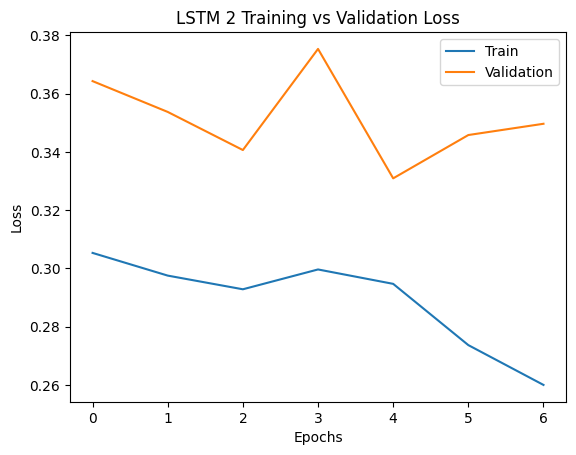

In [39]:
# Visual Of TRAINING CURVES

evaluator.plot_confusion_matrix(y_test, y_pred_lstm, model_name='LSTM 2')
evaluator.plot_metric_bar(metrics_lstm, model_name='LSTM 2')



plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM 2 Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.savefig('LSTM 2 Traning Curve.png', dpi=200, bbox_inches='tight')
plt.show()

### Bidirectional LSTM Model for Sentiment Analysis

The model demonstrated stable and consistent performance across training epochs, achieving a peak validation accuracy of 86.7%. The lowest validation loss was observed at epoch 5, indicating optimal generalization at this stage. While training accuracy continued to improve beyond epoch 6, a slight decline in validation performance suggests the onset of overfitting. The evaluation metrics (Precision: 0.8718, Recall: 0.8545, F1-score: 0.8631) confirm a well-balanced model with strong predictive capability.

Overall, the model demonstrates robust performance in capturing sentiment patterns, with good generalization and only moderate overfitting, confirming the effectiveness of the bidirectional LSTM architecture for this task.

### Gated Recurrent Unit (GRU) Model

The Gated Recurrent Unit (GRU) model is a simplified variant of LSTM designed to capture sequential dependencies in text data while using fewer parameters. By combining memory gates, GRUs achieve efficient learning with faster training times and reduced computational complexity. The model demonstrates strong performance in text classification tasks, providing a good balance between accuracy and efficiency while maintaining competitive results compared to more complex architectures like LSTM.

In [40]:

from tensorflow.keras.layers import GRU

print(" GRU MODEL")


# BUILD MODEL

gru_model = Sequential([
    Embedding(input_dim=10000, output_dim=64),
    GRU(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

## Training with early stopping
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


history_gru = gru_model.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[es]
)

 GRU MODEL
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 152ms/step - accuracy: 0.5413 - loss: 0.6927 - val_accuracy: 0.5086 - val_loss: 1.0864
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 75s 151ms/step - accuracy: 0.5996 - loss: 0.6553 - val_accuracy: 0.6970 - val_loss: 0.5763
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 152ms/step - accuracy: 0.8461 - loss: 0.3844 - val_accuracy: 0.8559 - val_loss: 0.3611
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 152ms/step - accuracy: 0.9099 - loss: 0.2434 - val_accuracy: 0.8798 - val_loss: 0.2923
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 152ms/step - accuracy: 0.9409 - loss: 0.1753 - val_accuracy: 0.8836 - val_loss: 0.2978
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 75s 150ms/step - accuracy: 0.9597 - loss: 0.1275 - val_accuracy: 0.8739 - val_loss: 0.3278


In [41]:

# METRICS EVALUATION 

y_prob_gru = gru_model.predict(X_test_seq)
metrics_gru, y_pred_gru = evaluate_dl(y_test, y_prob_gru)


313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step
Accuracy: 0.8809
Precision: 0.8494
Recall: 0.9282
F1-Score: 0.8871


#### GRU MODEL VISUALSATION

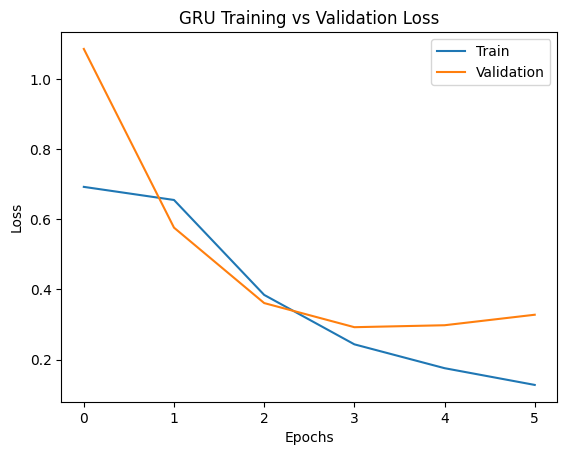

In [42]:
# VISUALS CONFUSION MATRIX NOT SAVING TO OS
evaluator.plot_confusion_matrix(y_test, y_pred_gru, model_name='GRU')

# VISUALs OF METRIC BAR SAVING TO OS
evaluator.plot_metric_bar(metrics_gru, model_name='GRU')



# VISUALS ON  TRAINING CURVES

plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])
plt.title('GRU Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.savefig('GRU Training Curve Plot.png', dpi=200, bbox_inches='tight')
plt.show()






### Gated Recurrent Unit (GRU) Model

The GRU model demonstrated superior performance compared to other models, achieving an accuracy of 88.1% and an F1-score of 0.8871. The model showed rapid learning between epochs 2 and 4, with peak validation accuracy observed at epoch 5. However, a noticeable divergence between training and validation performance after epoch 5 indicates the onset of overfitting. The model also exhibited a high recall (0.9282), suggesting strong capability in identifying positive instances, albeit with a slight trade-off in precision.


Overall, the GRU model provides a good balance between efficiency and predictive capability, but it is slightly less robust than the LSTM model for this task, particularly in terms of precision and overall classification performance.


### CNN for Text Classification

A Convolutional Neural Network (CNN) was applied to text classification and sentiment analysis, leveraging convolutional filters to capture important local patterns in text. The model efficiently extracts key features and delivers strong performance with faster training compared to recurrent models.

In [44]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D



# BUILDING THE MODEL
cnn_model = Sequential([
    Embedding(input_dim=10000, output_dim=64),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)


# TRAIN MODEL

history_cnn = cnn_model.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[es]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.7490 - loss: 0.4923 - val_accuracy: 0.8482 - val_loss: 0.3420
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.8724 - loss: 0.3049 - val_accuracy: 0.8705 - val_loss: 0.3080


In [45]:
# MERICS EVALUATION 

y_prob_cnn = cnn_model.predict(X_test_seq)
metrics_cnn, y_pred_cnn = evaluate_dl(y_test, y_prob_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Accuracy: 0.8579
Precision: 0.8458
Recall: 0.8782
F1-Score: 0.8616


#### CNN VISUALS

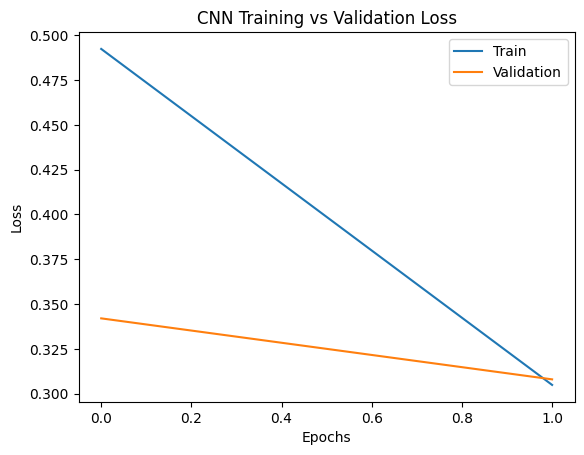

In [46]:
 # VISUALS 

evaluator.plot_confusion_matrix(y_test, y_pred_cnn, model_name='CNN')
evaluator.plot_metric_bar(metrics_cnn, model_name='CNN')



#  TRAINING CURVES VISUAL

plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title('CNN Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.savefig('CNN Training Cures.png', dpi=200, bbox_inches='tight')
plt.show()


#### MODEL COMPARISON SUMMARY (ALL MODELS)

In [66]:
results = pd.DataFrame([{"model": "RNN", **metrics_rnn},
    {"model": "LSTM", **metrics_lstm},
    {"model": "GRU", **metrics_gru},
    {"model": "CNN", **metrics_cnn}
])

print("Deep Learning model summary")

print(results)

Deep Learning model summary
  model  accuracy  precision    recall        f1
0   RNN    0.5363   0.525175  0.832110  0.643938
1  LSTM    0.8634   0.871836  0.854535  0.863099
2   GRU    0.8809   0.849437  0.928160  0.887055
3   CNN    0.8579   0.845757  0.878150  0.861649


In [59]:

# Collecting metrics after running ALL models:

results = pd.DataFrame([
    {"model": "Naive Bayes", **metrics_dict},
    {"model": "Logistic Regression", **metrics_log},
    {"model": "SVM", **metrics_svm},
    {"model": "Random Forest", **metrics_rf},
    {"model": "KNN", **metrics_knn},
    {"model": "RNN", **metrics_rnn},
    {"model": "LSTM", **metrics_lstm},
    {"model": "GRU", **metrics_gru},
    {"model": "CNN", **metrics_cnn}
])

# TABLE VIEW (FOR REPORT)

print("MODEL PERFORMANCE SUMMARY ")
print(results.sort_values(by='f', ascending=False))


MODEL PERFORMANCE SUMMARY 
                 model  accuracy  precision    recall        f1
1  Logistic Regression    0.8930   0.893221  0.893000  0.892973
7                  GRU    0.8809   0.849437  0.928160  0.887055
2                  SVM    0.8861   0.886258  0.886100  0.886077
6                 LSTM    0.8634   0.871836  0.854535  0.863099
8                  CNN    0.8579   0.845757  0.878150  0.861649
3        Random Forest    0.8564   0.856473  0.856400  0.856401
0          Naive Bayes    0.8487   0.848715  0.848700  0.848702
4                  KNN    0.7177   0.726583  0.717700  0.714542
5                  RNN    0.5363   0.525175  0.832110  0.643938


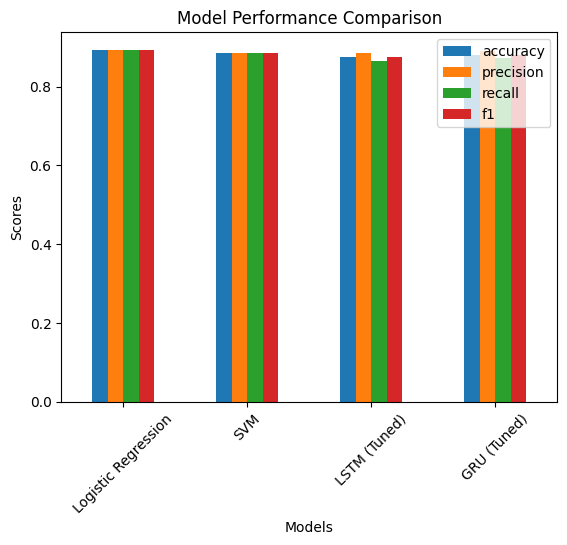

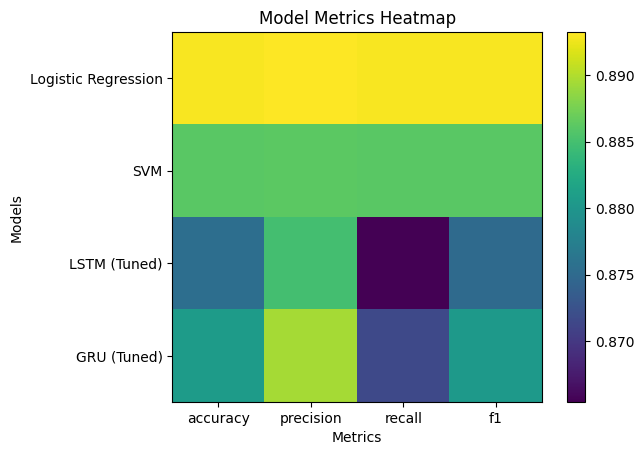

BEST MODEL
model        Logistic Regression
accuracy                   0.893
precision               0.893221
recall                     0.893
f1                      0.892973
Name: 0, dtype: object


In [95]:
# VISUALS BAR CHART COMPARISON

results.set_index('model')[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar')
plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Scores")
plt.xticks(rotation=45)
plt.savefig("DEEP Model Performance Comparison", dpi=200, bbox_inches='tight')
plt.show()


# VISUALS HEATMAP STYLE (MATRIX VIEW)
plt.imshow(results[['accuracy', 'precision', 'recall', 'f1']])
plt.title("Model Metrics Heatmap")
plt.xlabel("Metrics")
plt.ylabel("Models")
plt.xticks(ticks=range(4), labels=['accuracy','precision','recall','f1'])
plt.yticks(ticks=range(len(results)), labels=results['model'])
plt.colorbar()
plt.savefig("Model Metrics Heatmap.png", dpi=200, bbox_inches='tight')
plt.show()


# VISUALS  SHOWING BEST MODEL HIGHLIGHT

best_model = results.sort_values(by='f1', ascending=False).iloc[0]
print("BEST MODEL")
print(best_model)


### Deep Learning Model Performance Comparison

The performance of four deep learning models was evaluated using accuracy, precision, recall, and F1-score. The results highlight clear differences in how effectively each model captures patterns in the text classification task.

The **GRU model** achieved the best overall performance, with an accuracy of **0.8809** and an F1-score of **0.8871**. It also recorded the highest recall (**0.9282**), indicating a strong ability to correctly identify positive instances. This suggests that GRU effectively captures sequential dependencies while maintaining efficient training.

The **LSTM model** also performed strongly, with an accuracy of **0.8634** and an F1-score of **0.8631**. It demonstrated a well-balanced performance across precision and recall, highlighting its ability to model long-term dependencies and generalize effectively.

The **CNN model** achieved an accuracy of **0.8579** and an F1-score of **0.8616**, delivering competitive results. Its performance indicates that convolutional architectures are effective in extracting key local features from text, though slightly less powerful than recurrent models for capturing sequence information.

The **RNN model** showed the weakest performance, with an accuracy of **0.5363** and an F1-score of **0.6439**. Despite achieving a relatively high recall (**0.8321**), its low precision and accuracy suggest limitations in handling long-term dependencies and maintaining stable learning.

Overall, the GRU model emerged as the best-performing deep learning model, followed closely by LSTM and CNN. The results demonstrate that more advanced recurrent architectures outperform basic RNNs, with GRU providing the best balance between performance and computational efficiency for this task.

#### MACHINE LEARNING AUTO TUNNING PARAMETER AND TRAINING THE MODEL

In [67]:
class ModelTuner:
    def __init__(self, models, param_grids, scoring='f1'):
        self.models = models
        self.param_grids = param_grids
        self.scoring = scoring
        self.best_models = {}

    def tune_and_train(self, X_train, y_train):
        for name in self.models:
            print(f"\n Tuning {name}")

            grid = GridSearchCV(
                self.models[name],
                self.param_grids[name],
                cv=3,
                scoring=self.scoring,
                n_jobs=-1
            )

            grid.fit(X_train, y_train)

            self.best_models[name] = grid.best_estimator_

            print(f" Best Params for {name}: {grid.best_params_}")

In [68]:
#### AUTO EVALUATION

In [69]:
class ModelComparer:
    def __init__(self, evaluator):
        self.evaluator = evaluator
        self.results = []

    def evaluate_models(self, models, X_test, y_test):
        for name, model in models.items():
            print(f"\n Evaluating {name}")

            y_pred = model.predict(X_test)
            metrics = self.evaluator.evaluate(y_test, y_pred)

            self.results.append({
                "model": name,
                **metrics
            })

        return pd.DataFrame(self.results)

### DEFINIG MODEL AND PARAMETER  GRID

In [70]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC()
}

param_grids = {
    "Naive Bayes": {
        "alpha": [0.1, 0.5, 1.0]
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs", "liblinear"]
    },
    "SVM": {
        "C": [0.01, 0.1, 1, 10],
        "loss": ["hinge", "squared_hinge"]
    }
}

In [72]:
from sklearn.model_selection import GridSearchCV

# Initialize
evaluator = Evaluator()

tuner = ModelTuner(models, param_grids)
tuner.tune_and_train(X_train_tfidf, y_train)

# Compare
comparer = ModelComparer(evaluator)
results_df = comparer.evaluate_models(
    tuner.best_models,
    X_test_tfidf,
    y_test
)

print("\nFINAL MODEL COMPARISON ")
print(results_df.sort_values(by="f1", ascending=False))


 Tuning Naive Bayes
 Best Params for Naive Bayes: {'alpha': 0.5}

 Tuning Logistic Regression
 Best Params for Logistic Regression: {'C': 1, 'solver': 'lbfgs'}

 Tuning SVM
 Best Params for SVM: {'C': 1, 'loss': 'hinge'}

 Evaluating Naive Bayes
Accuracy: 0.8488
Precision (Weighted): 0.8488
Recall (Weighted): 0.8488
F1-Score (Weighted): 0.8488

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


 Evaluating Logistic Regression
Accuracy: 0.8930
Precision (Weighted): 0.8932
Recall (Weighted): 0.8930
F1-Score (Weighted): 0.8930

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1    

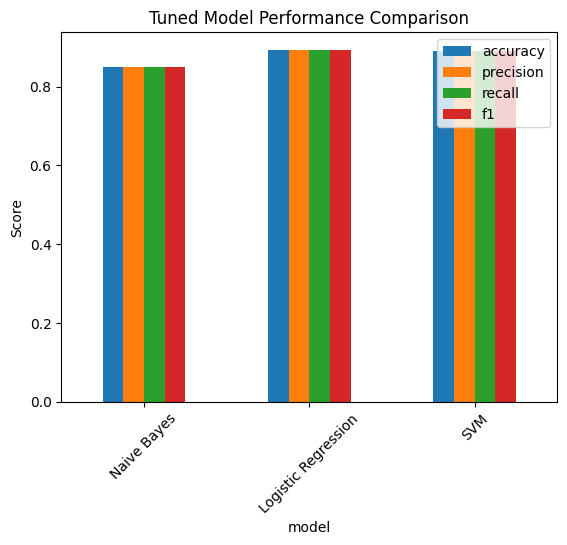

In [96]:
results_df.set_index("model")[["accuracy", "precision", "recall", "f1"]].plot(kind="bar")
plt.title("Tuned Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.savefig('Tuned ML Comparison.png', dpi=200, bbox_inches='tight')
plt.show()

#### DEEP LEARNING AUTO TUNNING PARAMETER AND TRAINING THE MODEL

In [76]:
from tensorflow.keras.layers import GRU
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

## LSTM HP TUNING
def build_lstm(hp):
    model = Sequential()

    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice('embedding_dim', [32, 64, 128])
    ))

    model.add(LSTM(
        units=hp.Int('units', min_value=32, max_value=128, step=32)
    ))

    model.add(Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice('lr', [1e-3, 1e-4, 1e-5])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model
    
    
## GRU PARAMETER TUNNIG

def build_gru(hp):
    model = Sequential()

    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice('embedding_dim', [32, 64, 128])
    ))

    model.add(GRU(
        units=hp.Int('units', min_value=32, max_value=128, step=32)
    ))

    model.add(Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice('lr', [1e-3, 1e-4, 1e-5])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

#### LSTM TUNING TRAINING

In [77]:
tuner_lstm = kt.RandomSearch(
    build_lstm,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuning',
    project_name='lstm_tuning'
)

tuner_lstm.search(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

best_lstm = tuner_lstm.get_best_models(1)[0]

Trial 5 Complete [00h 03m 55s]
val_accuracy: 0.5432500243186951

Best val_accuracy So Far: 0.8708750009536743
Total elapsed time: 00h 56m 55s


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


#### GRU TUNING TRAINING

In [78]:
tuner_gru = kt.RandomSearch(
    build_gru,
    objective='val_accuracy',
    max_trials=3,
    executions_per_trial=1,
    directory='tuning',
    project_name='gru_tuning'
)

tuner_gru.search(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

best_gru = tuner_gru.get_best_models(1)[0]

Trial 3 Complete [00h 14m 46s]
val_accuracy: 0.8768749833106995

Best val_accuracy So Far: 0.8772500157356262
Total elapsed time: 00h 34m 51s


#### TUNED MODEL EVALUATION FOR LSTM & GRU

In [79]:
# LSTM
y_prob_lstm = best_lstm.predict(X_test_seq)
metrics_lstm, y_pred_lstm = evaluate_dl(y_test, y_prob_lstm)

# GRU
y_prob_gru = best_gru.predict(X_test_seq)
metrics_gru, y_pred_gru = evaluate_dl(y_test, y_prob_gru)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step
Accuracy: 0.8755
Precision: 0.8849
Recall: 0.8654
F1-Score: 0.8751
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step
Accuracy: 0.8807
Precision: 0.8894
Recall: 0.8716
F1-Score: 0.8804


#### Tuned Model Comparism

In [81]:
results = pd.DataFrame([
    {"model": "Logistic Regression", **metrics_log},
    {"model": "SVM", **metrics_svm},
    {"model": "LSTM (Tuned)", **metrics_lstm},
    {"model": "GRU (Tuned)", **metrics_gru},
])

print(results)

                 model  accuracy  precision    recall        f1
0  Logistic Regression    0.8930   0.893221  0.893000  0.892973
1                  SVM    0.8861   0.886258  0.886100  0.886077
2         LSTM (Tuned)    0.8755   0.884943  0.865449  0.875088
3          GRU (Tuned)    0.8807   0.889429  0.871602  0.880425


#### Visualization of Results

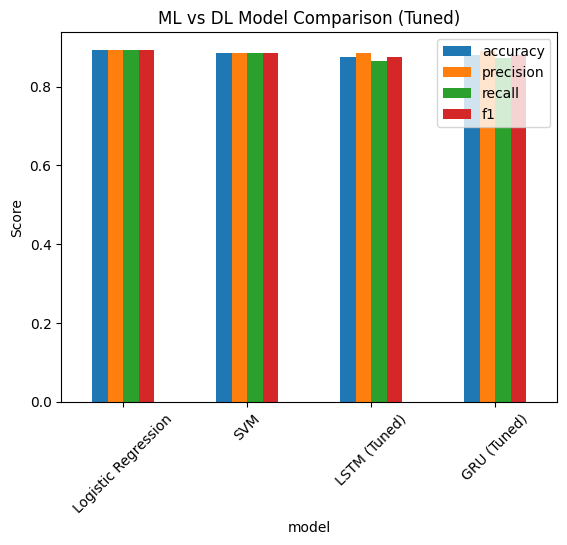

In [83]:
results.set_index('model')[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar')
plt.title("ML vs DL Model Comparison (Tuned)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.savefig('ML vs DL Model Comparison Tuned.png', dpi=200, bbox_inches='tight')
plt.show()

Hyperparameter tuning for deep learning models (LSTM and GRU) was conducted using Keras Tuner with a Random Search strategy. Key parameters such as embedding dimensions, number of hidden units, dropout rate, and learning rate were optimized. The objective was to maximize validation accuracy while minimizing overfitting. The tuned models were evaluated and compared with traditional machine learning models to assess performance improvements.